Dataset audit

In [1]:
from re import search

import pandas as pd
import numpy as np
from jupyter_builder.jupyterlab_semver import compare_identifiers
from sklearn.metrics import mean_absolute_error, mean_squared_error

df = pd.read_csv('../data/raw/dataset-2.csv')
df.info()
display(df.head())

print("=================================================================================")
print(df.describe())
print("=================================================================================")
print(df.columns)
print("=================================null================================================")
print(df.isnull().sum())
print("=================================nan================================================")
print(df.isna().sum())
print("===================================dup============================================")
print(df.duplicated().sum())
print("===================================shape============================================")
print(df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  str    
 1   Delivery_person_ID           45593 non-null  str    
 2   Delivery_person_Age          45593 non-null  str    
 3   Delivery_person_Ratings      45593 non-null  str    
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  str    
 9   Time_Orderd                  45593 non-null  str    
 10  Time_Order_picked            45593 non-null  str    
 11  Weatherconditions            45593 non-null  str    
 12  Road_traffic_density         45593 non-null  str    
 13  Vehicle_condition          

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


       Restaurant_latitude  Restaurant_longitude  Delivery_location_latitude  \
count         45593.000000          45593.000000                45593.000000   
mean             17.017729             70.231332                   17.465186   
std               8.185109             22.883647                    7.335122   
min             -30.905562            -88.366217                    0.010000   
25%              12.933284             73.170000                   12.988453   
50%              18.546947             75.898497                   18.633934   
75%              22.728163             78.044095                   22.785049   
max              30.914057             88.433452                   31.054057   

       Delivery_location_longitude  Vehicle_condition  
count                 45593.000000       45593.000000  
mean                     70.845702           1.023359  
std                      21.118812           0.839065  
min                       0.010000           0.000000  

identify the target

the target is the delivery time in minutes its the most important feature to predict , we can rely on it for prediction of the delivery time , its already integer and have a good name that indicate that the values are by minute .

In [2]:
target = df['Time_taken(min)']
print(target.head(3))
print(target.dtype)

data_dictionary = pd.DataFrame([
    ("ID", "Order identifier", "None", "Exclude: identifier"),
    ("Delivery_person_ID", "Courier identifier", "None", "Exclude: identifier"),
    ("Delivery_person_Age", "Courier age", "Years", "Predictor"),
    ("Delivery_person_Ratings", "Courier rating", "Score", "Predictor"),
    ("Restaurant_latitude", "Restaurant latitude", "Degrees", "Derive distance"),
    ("Restaurant_longitude", "Restaurant longitude", "Degrees", "Derive distance"),
    ("Delivery_location_latitude", "Customer latitude", "Degrees", "Derive distance"),
    ("Delivery_location_longitude", "Customer longitude", "Degrees", "Derive distance"),
    ("Order_Date", "Order date", "Date", "Derive date features"),
    ("Time_Orderd", "Order placement time", "Clock time", "Derive time features"),
    ("Time_Order_picked", "Courier pickup time", "Clock time", "Check availability/leakage"),
    ("Weatherconditions", "Weather condition", "Category", "Predictor"),
    ("Road_traffic_density", "Traffic level", "Category", "Predictor"),
    ("Vehicle_condition", "Vehicle condition level", "Ordinal", "Predictor"),
    ("Type_of_order", "Order category", "Category", "Predictor"),
    ("Type_of_vehicle", "Courier vehicle type", "Category", "Predictor"),
    ("multiple_deliveries", "Concurrent delivery count", "Count", "Predictor"),
    ("Festival", "Festival-day indicator", "Category", "Predictor"),
    ("City", "City category", "Category", "Predictor"),
    ("Time_taken(min)", "Observed delivery duration", "Minutes", "Target"),
], columns=["column", "meaning", "unit", "modeling_decision"])
data_dictionary.insert(2, "dtype", data_dictionary["column"].map(df.dtypes.astype(str)))

display(data_dictionary)

0    (min) 24
1    (min) 33
2    (min) 26
Name: Time_taken(min), dtype: str
str


,column,meaning,dtype,unit,modeling_decision
0,ID,Order identifier,str,None,Exclude: identifier
1,Delivery_person_ID,Courier identifier,str,None,Exclude: identifier
2,Delivery_person_Age,Courier age,str,Years,Predictor
3,Delivery_person_Ratings,Courier rating,str,Score,Predictor
4,Restaurant_latitude,Restaurant latitude,float64,Degrees,Derive distance
5,Restaurant_longitude,Restaurant longitude,float64,Degrees,Derive distance
6,Delivery_location_latitude,Customer latitude,float64,Degrees,Derive distance
7,Delivery_location_longitude,Customer longitude,float64,Degrees,Derive distance
8,Order_Date,Order date,str,Date,Derive date features
9,Time_Orderd,Order placement time,str,Clock time,Derive time features


cleaning data setup

In [3]:
from src.data import (
load_raw_data,
clean_delivery_data,
create_train_test_split,
)
raw_df = load_raw_data()


cleaned_df = clean_delivery_data(raw_df)

print("raw shape:", raw_df.shape)
print("cleaned shape:", cleaned_df.shape)
display(cleaned_df.head(3))
print(cleaned_df.isna().sum())
print("exact duplicates", raw_df.duplicated().sum())



raw shape: (45593, 20)
cleaned shape: (41953, 10)


,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Type_of_vehicle,Time_taken(min)
0,22.745049,75.892471,22.765049,75.912471,0 days 11:30:00,0 days 11:45:00,Sunny,2,Motorcycle,24
1,12.913041,77.683237,13.043041,77.813237,0 days 19:45:00,0 days 19:50:00,Stormy,3,Scooter,33
2,12.914264,77.678400,12.924264,77.688400,0 days 08:30:00,0 days 08:45:00,Sandstorms,0,Motorcycle,26


Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Type_of_vehicle                0
Time_taken(min)                0
dtype: int64
exact duplicates 0


Visualisation

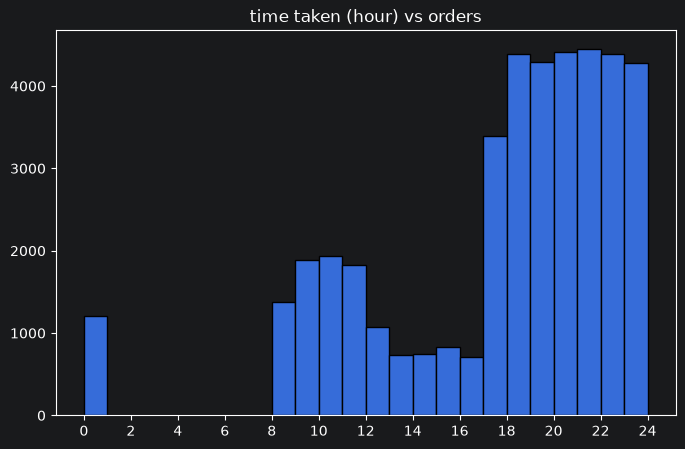

(41953, 10)


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns


#time takeny

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(
      cleaned_df["Time_Order_picked"].dt.total_seconds()/3600 ,
      bins=range(25),
      edgecolor="black"
  )
ax.set_title("time taken (hour) vs orders")
ax.set_xticks(range(0, 25, 2))
plt.show()
print(cleaned_df.shape)


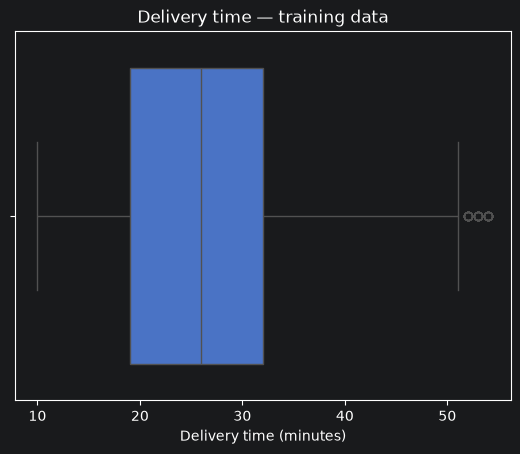

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x=cleaned_df["Time_taken(min)"])

plt.title("Delivery time — training data")
plt.xlabel("Delivery time (minutes)")
plt.show()

analyse descriptive

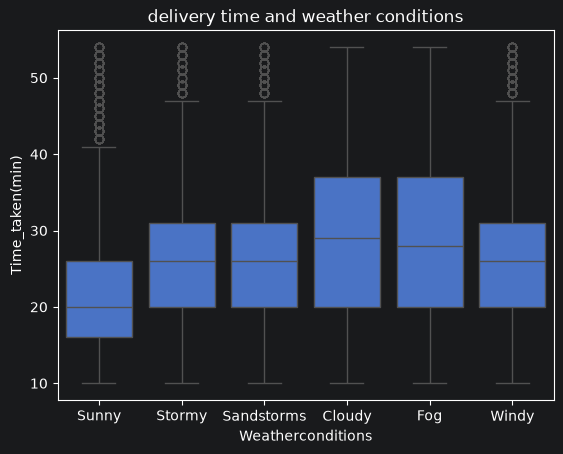

In [6]:

sns.boxplot(cleaned_df,y="Time_taken(min)", x="Weatherconditions")
plt.title("delivery time and weather conditions")
plt.show()


i think sunny has some outliers but if the distance between the restaurant and the delivery location is too far, it may take longer to deliver the food. this could be due to traffic or other factors that affect delivery time. it would be interesting to see if there is a correlation between traffic and delivery time.

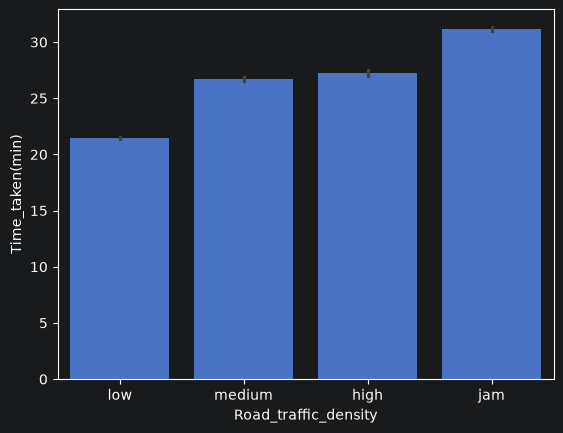

In [7]:
sns.barplot(
    data=cleaned_df,
    x="Road_traffic_density",
    y="Time_taken(min)",
)
plt.xticks([0,1,2,3], ["low", "medium", "high", "jam"])
plt.show()

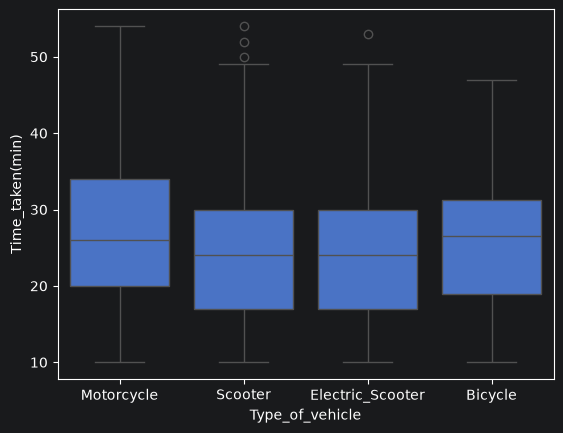

In [8]:
sns.boxplot(
    data=cleaned_df,
    x="Type_of_vehicle",
    y="Time_taken(min)",
)
plt.show()


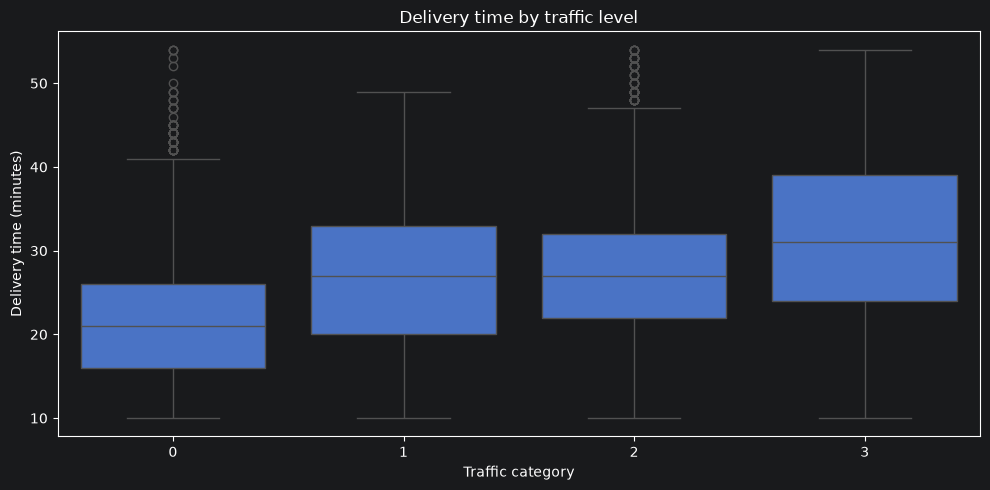

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(
    data=cleaned_df,
    x="Road_traffic_density",
    y="Time_taken(min)",
    ax=ax,
)

ax.set_title("Delivery time by traffic level")
ax.set_xlabel("Traffic category")
ax.set_ylabel("Delivery time (minutes)")

plt.tight_layout()
plt.show()

correlation matrice

In [10]:
corr = cleaned_df.loc[:,["Time_taken(min)", "Road_traffic_density"]].corr()
print(cleaned_df.loc[:,["Time_taken(min)", "Road_traffic_density"]].corr())

                      Time_taken(min)  Road_traffic_density
Time_taken(min)              1.000000              0.411793
Road_traffic_density         0.411793              1.000000


visualize correlation


<Axes: >

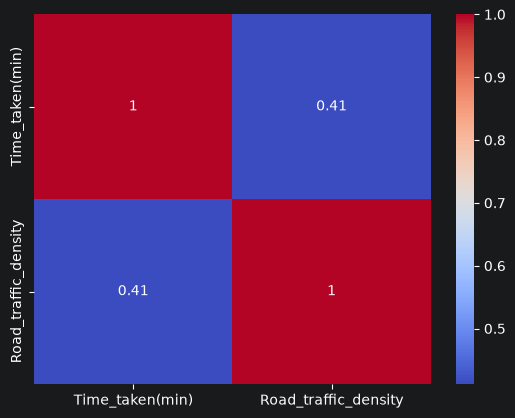

In [11]:
sns.heatmap(corr, annot=True, cmap="coolwarm")

Identifier les variables les plus fortement liées au temps de livraison.

Road traffic and weather conditions

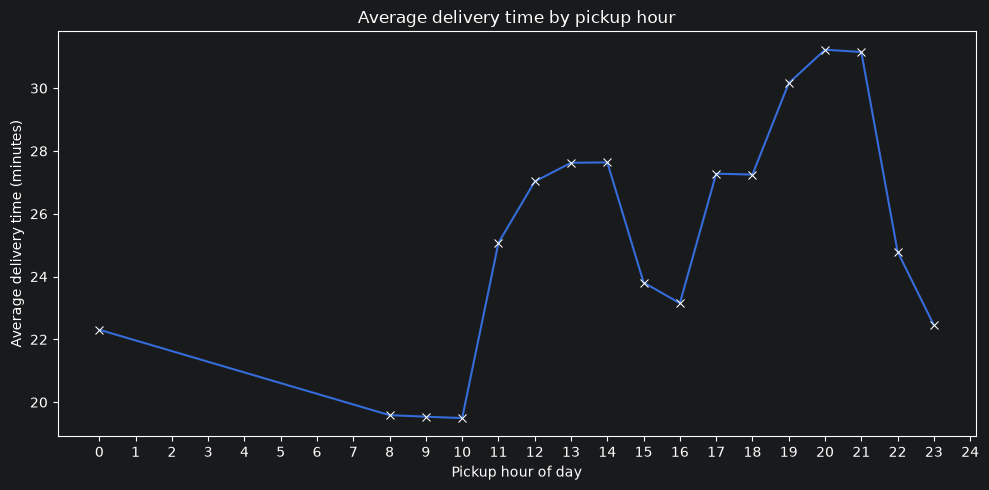

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = cleaned_df.copy()

# Extract whole pickup hours from timedelta values.
plot_df["pickup_hour"] = (
    (plot_df["Time_Order_picked"].dt.total_seconds() // 3600) % 24
).astype("Int64")

fig, ax = plt.subplots(figsize=(10, 5))

sns.lineplot(
    data=plot_df,
    x="pickup_hour",
    y="Time_taken(min)",
    estimator="mean",
    errorbar=None,
    marker="x",
    ax=ax,
)



ax.set_title("Average delivery time by pickup hour")
ax.set_xlabel("Pickup hour of day")
ax.set_ylabel("Average delivery time (minutes)")
ax.set_xticks(range(25))
plt.tight_layout()
plt.show()

add  two features


In [30]:
from src.features import create_features
df_features = create_features(cleaned_df)
display(df_features.head())

,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Type_of_vehicle,Time_taken(min),distance_km,order_hour
0,22.745049,75.892471,22.765049,75.912471,0 days 11:30:00,0 days 11:45:00,Sunny,2,Motorcycle,24,3.025153,11
1,12.913041,77.683237,13.043041,77.813237,0 days 19:45:00,0 days 19:50:00,Stormy,3,Scooter,33,20.183558,19
2,12.914264,77.678400,12.924264,77.688400,0 days 08:30:00,0 days 08:45:00,Sandstorms,0,Motorcycle,26,1.552760,8
3,11.003669,76.976494,11.053669,77.026494,0 days 18:00:00,0 days 18:10:00,Sunny,1,Motorcycle,21,7.790412,18
4,12.972793,80.249982,13.012793,80.289982,0 days 13:30:00,0 days 13:45:00,Cloudy,2,Scooter,30,6.210147,13


Training Data

In [20]:
from src.data import *
from src.train import *
from src.features import *
import pandas as pd

raw = load_raw_data()
cleaned = clean_delivery_data(raw)
featured = create_features(cleaned)

print(featured[
  [
      "distance_km",
      "Road_traffic_density",
      "order_hour",
      "Weatherconditions",
      "Type_of_vehicle",
      "Time_taken(min)",
  ]
].head())

X_train, X_test, y_train, y_test = create_train_test_split(featured)
print("xtrain:", X_train.shape)
print("xtest:", X_test.shape)
print("ytrain:", y_train.shape)
print("ytest:", y_test.shape)



cv_results = cross_validate_pipelines(X_train, y_train)
cv_df = pd.DataFrame(cv_results).T
cv_df = cv_df.sort_values("validation_mae")
display(cv_df)

   distance_km Road_traffic_density  order_hour Weatherconditions  \
0     3.025153                    2          11             Sunny   
1    20.183558                    3          19            Stormy   
2     1.552760                    0           8        Sandstorms   
3     7.790412                    1          18             Sunny   
4     6.210147                    2          13            Cloudy   

  Type_of_vehicle  Time_taken(min)  
0      Motorcycle               24  
1         Scooter               33  
2      Motorcycle               26  
3      Motorcycle               21  
4         Scooter               30  
xtrain: (33562, 11)
xtest: (8391, 11)
ytrain: (33562,)
ytest: (8391,)


,validation_mae,validation_mse,validation_rmse,validation_r2,training_mae,fit_time
random_forest,5.349598,46.805990,6.841156,0.470849,4.556349,1.001630
ridge_regression,6.255075,60.013364,7.746591,0.321492,6.252341,0.049891
linear_regression,6.255080,60.013542,7.746603,0.321490,6.252333,0.061724
decision_tree,7.195223,88.704614,9.417996,-0.003060,0.360182,0.106588
dummy_baseline,7.584291,88.560439,9.410452,-0.001214,7.584292,0.043716


Optimazing

In [25]:
from src.tuning import *

random_forest_tune = tune_model("random_forest", X_train, y_train)


Fitting 5 folds for each of 15 candidates, totalling 75 fits


KeyboardInterrupt: 

In [52]:
print(pd.DataFrame( random_forest_tune.best_params_.items(), columns=["parameter", "value"]))
print(-random_forest_tune.best_score_.best_mae)



                  parameter  value
0       model__n_estimators  500.0
1  model__min_samples_split    5.0
2   model__min_samples_leaf    2.0
3       model__max_features    0.7
4          model__max_depth    8.0


AttributeError: 'numpy.float64' object has no attribute 'best_mae'

In [53]:
test = random_forest_tune.best_estimator_.predict(X_test)
comparison_df = pd.DataFrame({
    "actual_value": y_test,
    "predicted_value": test
})

comparison_df["error"] = comparison_df["actual_value"] - comparison_df["predicted_value"]
comparison_df["absolute_error"] = comparison_df["error"].abs()
display(comparison_df.head())


,actual_value,predicted_value,error,absolute_error
20657,21,21.838054,-0.838054,0.838054
17666,18,20.354170,-2.354170,2.354170
4615,25,35.047063,-10.047063,10.047063
39337,24,22.576720,1.423280,1.423280
8357,40,27.846180,12.153820,12.153820


In [58]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

display(cv_df.T.head(1))
print( mean_absolute_error(y_test, test))
print( mean_squared_error(y_test, test))
print( r2_score(y_test, test))
print( root_mean_squared_error(y_test, test))


,validation_mae,validation_mse,validation_rmse,validation_r2,training_mae,fit_time
random_forest,5.349598,46.80599,6.841156,0.470849,4.556349,1.00163


5.177764125135159
43.252441747977976
0.4979758573666012
6.576658859023933
